# Lab 1 (simplified) · Part 1 — Train a network to forecast airport traffic
### EUROCONTROL AI Lab · Exercise 1S-1

**The question:** how many flights (IFR arrivals + departures) will **Brussels airport** have **tomorrow**?
**What the network sees:** the traffic of the **last 7 days** and the **day of the week** of tomorrow.

| | |
|---|---|
| ⏱ **Time** | about 45 minutes |
| 🎯 **You will** | train a small neural network, then **change its settings** (the *hyperparameters*) and see what happens on the training, validation and test days |

**What you will learn**
1. How a forecasting question becomes **examples** (inputs + answer) for a neural network.
2. What happens during **training**, and how to read **learning curves**.
3. What the **hyperparameters** do: network size, learning rate, number of epochs, batch size.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab1_simplified/1S-1_train.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab1_simplified")    # work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup

In [2]:
import json                                       # json: reads and writes small text files with settings
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import torch                                      # PyTorch: neural networks
import torch.nn as nn                             # building blocks of neural networks

DATA_DIR = Path("../data")                        # the data folder, next to this lab's folder
ARTIFACTS = Path("artifacts")                     # where the trained model is saved

SEED = 42                                         # a fixed starting point for random numbers...
torch.manual_seed(SEED)                           # ...so everyone gets the same results

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

---
## 1 · The data
Daily traffic at Brussels (EBBR) from the EUROCONTROL Aviation Intelligence Unit, 2023–2025.

Days: 1096 from 2023-01-01 to 2025-12-31


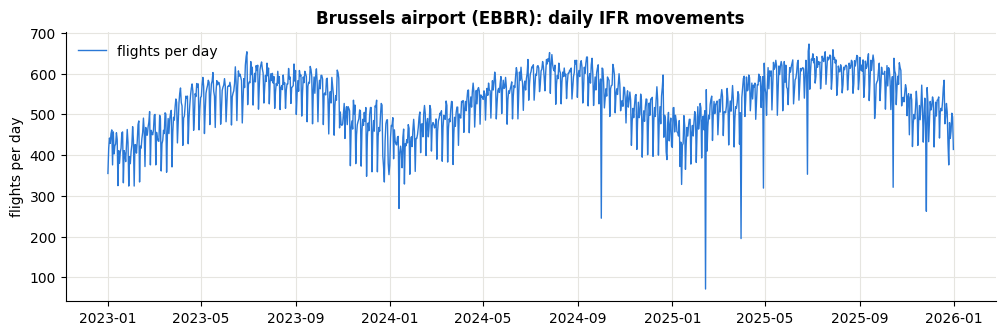

In [3]:
tables = []                                                      # one table per year
for year in [2023, 2024, 2025]:                                  # the three years we use
    tables.append(pd.read_csv(DATA_DIR / ("airport_traffic_" + str(year) + ".csv")))   # read the file of that year
traffic = pd.concat(tables)                                      # put the three years one after the other
traffic = traffic[traffic["APT_ICAO"] == "EBBR"]                 # keep only Brussels airport (EBBR)
traffic["FLT_DATE"] = pd.to_datetime(traffic["FLT_DATE"])        # turn the text dates into real dates
traffic = traffic.sort_values("FLT_DATE")                        # sort by date
series = pd.Series(traffic["FLT_TOT_1"].values, index=traffic["FLT_DATE"].values)   # flights per day, labelled by date

print("Days:", len(series), "from", series.index[0].date(), "to", series.index[-1].date())   # how much data

plt.figure(figsize=(12, 3.5))                                    # new figure
plt.plot(series.index, series.values, color=PALETTE[0], linewidth=1, label="flights per day")   # the daily traffic
plt.ylabel("flights per day")                                    # axis label
plt.title("Brussels airport (EBBR): daily IFR movements")        # title
plt.legend()                                                     # legend
plt.show()                                                       # display

📖 **Reading:** a strong **weekly rhythm** (the zig-zag), a seasonal rise in summer, and a few sudden drops (strikes, holidays). The network will have to learn the weekly rhythm from the data.

---
## 2 · From the data to examples
Each **example** is one day to forecast. The network receives **14 numbers** and must answer **1 number**:

```
 traffic of the 7 previous days   +   7 weekday switches (one is 1, the others 0)   ──►   NETWORK   ──►   traffic of the day
   e.g. 540 512 498 ... 571               e.g. 0 0 0 0 0 1 0  (= Saturday)                               e.g. 534
```

In [4]:
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]   # order of the 7 weekday switches
values = series.values.astype("float32")                         # the daily traffic, as plain numbers
X_list = []                                                      # the inputs of every example
y_list = []                                                      # the answer (true traffic) of every example
dates_list = []                                                  # the date of the day to forecast
for t in range(7, len(values)):                                  # every day that has 7 days before it
    past_7_days = values[t - 7:t]                                # traffic of the 7 previous days (oldest first)
    weekday_switches = np.zeros(7, dtype="float32")              # seven switches, all off...
    weekday_switches[series.index[t].dayofweek] = 1.0            # ...switch on the weekday of the day to forecast
    X_list.append(np.concatenate([past_7_days, weekday_switches]))   # the 14 inputs of this example
    y_list.append(values[t])                                     # the answer: the traffic of day t
    dates_list.append(series.index[t])                           # the date of day t
X = np.array(X_list)                                             # all inputs: one row per example, 14 columns
y = np.array(y_list)                                             # all answers
dates = pd.DatetimeIndex(dates_list)                             # all dates

example = pd.DataFrame([X[0]], columns=["7 d before", "6 d before", "5 d before", "4 d before", "3 d before", "2 d before",
                                        "yesterday"] + WEEKDAYS)  # the first example, as a readable table
example["→ ANSWER (truth)"] = y[0]                                # add its answer
print("Number of examples:", len(X))                             # how many examples
print("The first example, for", dates[0].date(), "(" + dates[0].day_name() + "):")   # which day it is
example                                                          # display it

Number of examples: 1089
The first example, for 2023-01-08 (Sunday):


,7 d before,6 d before,5 d before,4 d before,3 d before,2 d before,yesterday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,→ ANSWER (truth)
0,355.0,417.0,442.0,429.0,453.0,462.0,376.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,457.0


We split the examples **by time**: the network learns on the past and is checked on later days it has never seen.

| period | days | used for |
|---|---|---|
| **training** | 2023 – 2024 | the network learns from these |
| **validation** | January – June 2025 | we compare settings on these |
| **test** | July – December 2025 | a final check on days never used before |

In [5]:
is_train = dates < "2025-01-01"                                  # True for the training days
is_validation = (dates >= "2025-01-01") & (dates < "2025-07-01") # True for the validation days
is_test = dates >= "2025-07-01"                                  # True for the test days
print("Training:", is_train.sum(), "days · validation:", is_validation.sum(), "· test:", is_test.sum())   # sizes

baseline = X[:, 0]                                               # simple forecast: "same as the same weekday last week"
baseline_error = np.abs(baseline - y)                            # its error on every day
print("Baseline 'same weekday last week' — average error:")      # the number to beat
print("   training", round(baseline_error[is_train].mean(), 1), "· validation", round(baseline_error[is_validation].mean(), 1),
      "· test", round(baseline_error[is_test].mean(), 1), "flights per day")

Training: 724 days · validation: 181 · test: 184
Baseline 'same weekday last week' — average error:
   training 18.9 · validation 33.5 · test 25.9 flights per day


📖 **Reading:** the simple rule *"same as the same weekday last week"* is wrong by about 19 to 34 flights per day on average, depending on the period. **These are the numbers to beat.**

**Scaling.** Networks learn better with numbers around 0. We turn every traffic number into *"how far from the usual traffic"*, using the average and spread of the **training** days only.
The weekday switches stay 0 or 1.

In [6]:
MEAN = y[is_train].mean()                                        # average daily traffic of the training days
STD = y[is_train].std()                                          # its spread
X_scaled = X.copy()                                              # a copy of the inputs...
X_scaled[:, :7] = (X[:, :7] - MEAN) / STD                        # ...with the 7 traffic numbers scaled
y_scaled = (y - MEAN) / STD                                      # the answers, scaled the same way
print("Average:", round(float(MEAN), 1), "flights · spread:", round(float(STD), 1))   # the two scaling numbers

Average: 523.1 flights · spread: 70.5


---
## 3 · ⚙️ The settings — change them here
These four numbers are the **hyperparameters**: we choose them, the network does not learn them.

> 🧪 **How to experiment:** change one or more numbers in the next cell, then click it and use **Run → Run selected cell and all below**
> (in Colab: **Runtime → Run cell and below**). Every attempt is added to your table of attempts in §6. Nothing can break: if something looks wrong,
> put back the original values (16, 0.001, 100, 32) and run again.

In [7]:
HIDDEN = 16             # neurons in the hidden layer.           Try: 1, 4, 64, 256
LEARNING_RATE = 0.001   # size of each correction step.          Try: 0.00001, 0.01, 0.1, 1
EPOCHS = 100            # passes over all the training days.     Try: 5, 30, 300
BATCH_SIZE = 32         # days seen before each correction.      Try: 4, 128, 724 (= all the training days)

---
## 4 · The network
One hidden layer of `HIDDEN` neurons between the 14 inputs and the output:

```
14 inputs  ──►  [ HIDDEN neurons, with ReLU ]  ──►  1 output (tomorrow's traffic, scaled)
```

In [8]:
class TrafficNet(nn.Module):                                     # our neural network
    def __init__(self, hidden):                                  # runs when the network is created
        super().__init__()                                       # standard first line of every PyTorch model
        self.layer1 = nn.Linear(14, hidden)                      # hidden layer: 14 inputs -> `hidden` neurons
        self.output = nn.Linear(hidden, 1)                       # output layer: `hidden` neurons -> 1 number
        self.relu = nn.ReLU()                                    # keeps positive values, sets negative ones to 0

    def forward(self, x):                                        # what the network does with a batch of inputs
        h = self.relu(self.layer1(x))                            # the values (activations) of the hidden neurons
        return self.output(h).squeeze(1)                         # one number per example: the forecast (scaled)


torch.manual_seed(SEED)                                          # same random start for every attempt
model = TrafficNet(HIDDEN)                                       # create the network with the chosen size
number_of_weights = 0                                            # counter
for parameter in model.parameters():                             # for each table of weights...
    number_of_weights = number_of_weights + parameter.numel()    # ...add its size
print(model)                                                     # its structure
print("Weights to learn:", number_of_weights)                    # how many numbers training will set

TrafficNet(
  (layer1): Linear(in_features=14, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)
Weights to learn: 257


---
## 5 · Training
At every step the network receives a **batch** of days, makes its forecasts, measures how wrong they are (the **loss**), and corrects its weights a little.
After each epoch we measure the average error, in flights, on the **training** and **validation** days.

In [9]:
train_inputs = torch.tensor(X_scaled[is_train])                  # training inputs, as PyTorch tensors
train_answers = torch.tensor(y_scaled[is_train])                 # training answers
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(train_inputs, train_answers),
                                     batch_size=BATCH_SIZE, shuffle=True)   # cuts the training days into shuffled batches
loss_function = nn.MSELoss()                                     # loss = average of the squared errors
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)   # the method that corrects the weights


def average_error(rows):                                         # average error in flights on the chosen days
    model.eval()                                                 # evaluation mode: no learning
    with torch.no_grad():                                        # only forecasting
        forecasts = model(torch.tensor(X_scaled[rows])).numpy() * STD + MEAN   # forecasts, back in flights
    return float(np.abs(forecasts - y[rows]).mean())             # average size of the errors


train_curve = []                                                 # training error after each epoch
validation_curve = []                                            # validation error after each epoch
for epoch in range(EPOCHS):                                      # repeat EPOCHS times
    model.train()                                                # training mode
    for inputs, answers in loader:                               # for every batch of days:
        optimizer.zero_grad()                                    #   1. reset the previous corrections
        forecasts = model(inputs)                                #   2. the network makes its forecasts
        loss = loss_function(forecasts, answers)                 #   3. how wrong are they?
        loss.backward()                                          #   4. compute the corrections
        optimizer.step()                                         #   5. apply them
    train_curve.append(average_error(is_train))                  # error on the training days after this epoch
    validation_curve.append(average_error(is_validation))        # error on the validation days after this epoch
    if (epoch + 1) % max(1, EPOCHS // 5) == 0:                   # five times during training...
        print("epoch", epoch + 1, " training error", round(train_curve[-1], 1), " validation error", round(validation_curve[-1], 1))   # ...progress

epoch 20  training error 15.4  validation error 30.5


epoch 40  training error 14.4  validation error 29.3


epoch 60  training error 14.0  validation error 28.8


epoch 80  training error 13.7  validation error 28.5


epoch 100  training error 13.6  validation error 28.5


---
## 6 · Results
### 6.1 Learning curves

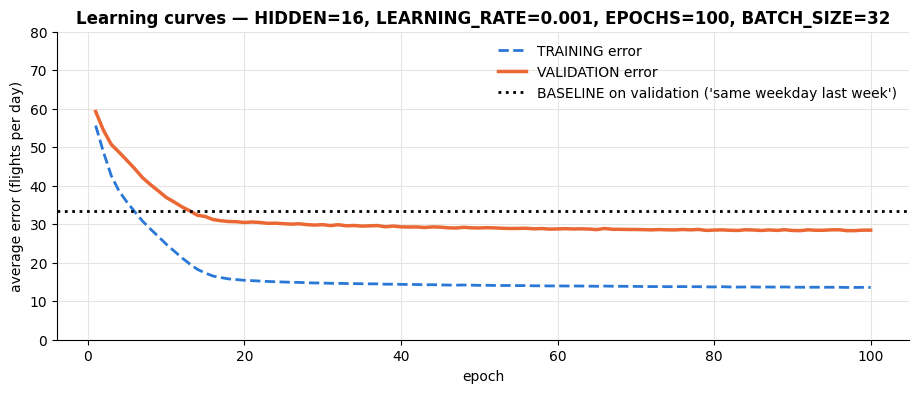

In [10]:
plt.figure(figsize=(11, 4))                                      # new figure
plt.plot(range(1, EPOCHS + 1), train_curve, color=PALETTE[0], linestyle="--", label="TRAINING error")       # training
plt.plot(range(1, EPOCHS + 1), validation_curve, color=PALETTE[1], linewidth=2.5, label="VALIDATION error")  # validation
plt.axhline(baseline_error[is_validation].mean(), color="black", linestyle=":",
            label="BASELINE on validation ('same weekday last week')")   # the number to beat
plt.ylim(0, 80)                                                  # vertical axis from 0 to 80 flights
plt.xlabel("epoch")                                              # axis label
plt.ylabel("average error (flights per day)")                    # axis label
plt.title("Learning curves — HIDDEN=" + str(HIDDEN) + ", LEARNING_RATE=" + str(LEARNING_RATE) +
          ", EPOCHS=" + str(EPOCHS) + ", BATCH_SIZE=" + str(BATCH_SIZE))   # title with the settings
plt.legend()                                                     # legend
plt.show()                                                       # display

📖 **How to read it:**
- both curves going **down** = the network is learning;
- **training** much lower than **validation** = the network memorises the training days instead of learning general rules (**overfitting**);
- curves still going down at the end = more epochs could help; curves jumping up and down = the learning rate is probably too large;
- below the dotted line = better than the simple baseline.

### 6.2 Training, validation and test in one table

In [11]:
errors = pd.DataFrame(index=["training (2023–24)", "validation (Jan–Jun 2025)", "test (Jul–Dec 2025)"])   # one row per period
errors["network (flights)"] = [round(average_error(is_train), 1), round(average_error(is_validation), 1),
                               round(average_error(is_test), 1)]  # the network's average errors
errors["baseline (flights)"] = [round(baseline_error[is_train].mean(), 1), round(baseline_error[is_validation].mean(), 1),
                                round(baseline_error[is_test].mean(), 1)]   # the baseline's average errors
errors                                                           # display the table

,network (flights),baseline (flights)
training (2023–24),13.6,18.9
validation (Jan–Jun 2025),28.5,33.5
test (Jul–Dec 2025),21.0,25.9


📖 **Reading (default settings):** the network beats the baseline on all three periods. The test period was never used to choose anything, so its error is an honest estimate of how the network would do on new days.

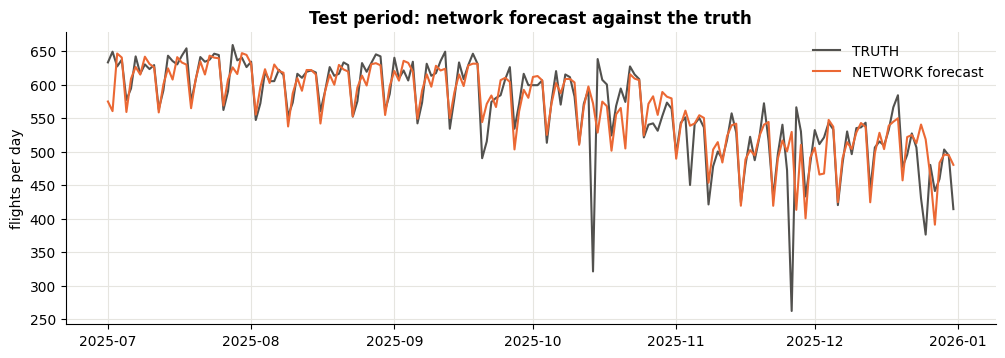

In [12]:
model.eval()                                                     # evaluation mode
with torch.no_grad():                                            # only forecasting
    test_forecasts = model(torch.tensor(X_scaled[is_test])).numpy() * STD + MEAN   # forecasts for the test days, in flights

plt.figure(figsize=(12, 3.8))                                    # new figure
plt.plot(dates[is_test], y[is_test], color="#52514e", linewidth=1.5, label="TRUTH")             # what happened
plt.plot(dates[is_test], test_forecasts, color=PALETTE[1], linewidth=1.5, label="NETWORK forecast")   # the forecasts
plt.ylabel("flights per day")                                    # axis label
plt.title("Test period: network forecast against the truth")     # title
plt.legend()                                                     # legend
plt.show()                                                       # display

📖 **Reading:** the network follows the weekly rhythm well. The large misses are unusual days (strikes, holidays) that the last 7 days could not announce.

### 6.3 Your table of attempts
Every time you run this cell, the current settings and results are added to `my_attempts.csv` in this folder. Compare your attempts here — but **choose with the validation column**:
the test column is the final exam, not the training ground.

In [13]:
attempt = {"HIDDEN": HIDDEN, "LEARNING_RATE": LEARNING_RATE, "EPOCHS": EPOCHS, "BATCH_SIZE": BATCH_SIZE,
           "training": round(average_error(is_train), 1), "validation": round(average_error(is_validation), 1),
           "test": round(average_error(is_test), 1)}             # this attempt: settings + errors
log_file = Path("my_attempts.csv")                               # the file that keeps all your attempts
if log_file.exists():                                            # if there are earlier attempts...
    attempts = pd.read_csv(log_file)                             # ...read them
else:                                                            # otherwise...
    attempts = pd.DataFrame()                                    # ...start an empty table
attempts = pd.concat([attempts, pd.DataFrame([attempt])], ignore_index=True)   # add this attempt
attempts.to_csv(log_file, index=False)                           # save the table
attempts.sort_values("validation")                               # display it, best validation error first
# To start again from an empty table, delete the file my_attempts.csv in this folder.

,HIDDEN,LEARNING_RATE,EPOCHS,BATCH_SIZE,training,validation,test
0,16,0.001,100,32,13.6,28.5,21.0


---
## 7 · Save the model for Parts 2 and 3
Parts 2 and 3 use the model saved here. Run this cell when you are happy with your settings.
A ready-trained model with the default settings is already in the `artifacts` folder.

In [14]:
ARTIFACTS.mkdir(exist_ok=True)                                   # create the folder if needed
torch.save(model.state_dict(), ARTIFACTS / "traffic_net.pt")     # the learned weights
settings = {"HIDDEN": HIDDEN, "MEAN": float(MEAN), "STD": float(STD)}   # what is needed to use them again
(ARTIFACTS / "traffic_net.json").write_text(json.dumps(settings, indent=2))   # saved as a small text file
print("Saved:", settings)                                        # confirm

Saved: {'HIDDEN': 16, 'MEAN': 523.0621337890625, 'STD': 70.49893188476562}


---
## 8 · Questions for discussion
1. Which setting changed the results the most in your attempts? Which one hardly mattered?
2. Find settings where the training error is much lower than the validation error. What is the network doing?
3. Why do we choose the settings with the validation days and not with the test days?